# Fitting the UDS with bagpus: full walkthrough

This notebook reproduces the analysis of the bagpus release paper: inferring the population distributions of star-formation-history and dust parameters for massive galaxies at $1.7<z<2.0$ in the UKIDSS UDS field, from the observed distribution of their super-colours.

**Data requirements** (not shipped with the repository — see the *Data* documentation page):

* `DR11-2arcsec-Jun-30-2019.fits` — UDS DR11 photometry catalogue
* `TDL_VWSC_0.5_3.024.5_dr11.fits` — super-colour catalogue
* CB19 stellar grids for bagpipes in `Bagpipes_grids/`

The eigenbasis and filter files **are** included in the repository.

**Runtime**: the simulation and training cells take hours at full scale. Every product is cached in `runs/`, so already-computed steps load instantly — you can safely run the notebook top to bottom after a cluster run of `scripts/step2_simulate.py`.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import bagpus

data_dir = '../UDS/'
filter_dir = '../FILTERS/'

## 1. Stellar library

The paper uses the CB19 (Charlot & Bruzual 2019) models, which are available from https://www.bruzual.org. This switches the grids inside your bagpipes installation. You do not need to download the original CB19 models, but you do need the pre-computed bagpipes grids. 

In [2]:
bagpus.grids.change_grid(neb_grid_name='cb19', stellar_grid_name='cb19',
                         grid_dir_name='../Bagpipes_grids/')

Bagpipes: Latex turned off in rcParams, plots may look strange.


Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


## 2. Load and select the sample

This block and the next block are **dataset-specific** — they are the only part of the workflow you need to rewrite for a different survey. We select $1.7<z<2.0$, $K \le 24$, $\log_{10}(M_*/M_\odot) > 10.3$, and well-measured super-colours.

In [3]:
from astropy.table import Table, join

zmin, zmax = 1.7, 2.0
klim, masslim = 24.0, 10.3

udsdr11 = join(Table.read(data_dir + 'TDL_VWSC_0.5_3.024.5_dr11.fits'),
               Table.read(data_dir + 'DR11-2arcsec-Jun-30-2019.fits'), keys='ID')

ind = np.where((udsdr11['CHISQ'] < 3) & np.isfinite(udsdr11['CHISQ'])
               & (udsdr11['SC'][:, 0] > -50)
               & (udsdr11['KMAG'] <= klim)
               & (udsdr11['MASS_SC'][:, 1] > masslim)
               & (udsdr11['ZUSED'] > zmin) & (udsdr11['ZUSED'] < zmax))
udsdata = udsdr11[ind]
print(len(udsdata), 'galaxies; median z =', round(np.median(udsdata['ZUSED']), 3))

2745 galaxies; median z = 1.822


## 3. Build the Observations

`Observations` contains all the obesrvable information needed. This is from Block 2, and also includes the relevant filters and eigen-basis that defines the linear combination of observed frame filters used for the super-colours. If you change the dataset or filters, you will need a new eigen-basis. 

The code uses an empirical noise model: the SC uncertainties as a function of SC1, using the brighter half of the sample (via `mag`) to isolate the noise floor. For this reason you need to give it an apparent magnitude - there are no doubt clever ways to do this. The simulator perturbs every model galaxy with noise drawn from this model, so simulated and observed distributions are directly comparable.

10 eigenvectors extracted
Minimum redshift of the eigenbasis: 0.5
Maximum redshift of the eigenbasis: 3.0


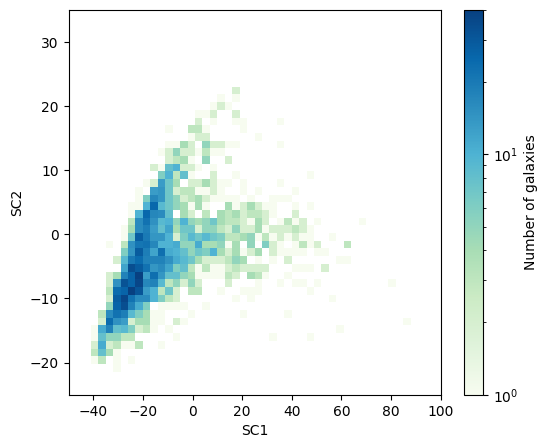

In [4]:
obs = bagpus.Observations(
    sc=np.array(udsdata['SC']), sc_err=np.array(udsdata['SCERR']),
    redshifts=np.array(udsdata['ZUSED']), mag=np.array(udsdata['KMAG']),
    eigenbasis_file=data_dir + 'VWSC_eigenbasis_0p5z3_wavemin2500.fits',
    filter_list_file=filter_dir + 'vwsc_uds.lis',
    filter_dir=filter_dir,
    n_eigenvectors=3,          # the UDS super-colours use 3 components
    pdf_range=[[-50, 100], [-25, 35]], pdf_bins=[50, 55],
    filter_mask=[9, 10],       # HST bands not used in the data
    zmin=zmin, zmax=zmax,
)
obs.plot();

## 4. The population model

The double power-law SFH is parameterised by the peak time $t_p$, rising slope $\log_{10}\beta$, and the quenching half-life $\log_{10}\tau_{1/2}$ (labelled $\gamma$ in plots). Dust follows a Calzetti law with an Av–sSFR relation. See the paper for the motivation of each prior range.

In [5]:
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70., Om0=0.3)
t_zmax = cosmo.age(zmax).value

pop_instructions = {
    "sfh": {
        "type": "dblplaw",
        "tau":        {"limits": (0.2, 1.5 * t_zmax), "mu": (2.0, 4.0), "sigma": (0.5, 2.0)},
        "logbeta":    {"limits": (-1.0, 2.0), "mu": (-1.0, 3.0), "sigma": (0.5, 2.0)},
        "logtauhalf": {"limits": (-2.0, 1.0), "mu": (-2.0, 1.0), "sigma": (0.1, 1.0)},
    },
    "dust": {
        "type": "Calzetti",
        "eta":      {"limits": (1.0, 3.0), "mu": (1.0, 2.0), "sigma": (0.2, 2.0)},
        "logAvint": {"limits": (0.8, 2.0), "mu": (1.2, 1.5), "sigma": (0.1, 0.2)},
    },
    "metallicity": {"limits": (0.5, 2.5), "mu": (0.5, 2.0), "sigma": (0.2, 2.0)},
}

model = bagpus.PopulationModel(pop_instructions, obs, cosmology=cosmo)
fit = bagpus.Fit(model, run='1.7_2.0_hyp2', working_dir='../runs/',
                 ngal_sims=7000, ncores=8)

### Check the prior

Before any expensive simulation, look at what the priors imply for the galaxy parameters and their derived properties (sSFR, formation and quenching times, quenched fraction). E.g. have you inadvertently set a prior that fixes your quenched fraction to a very narrow range? 

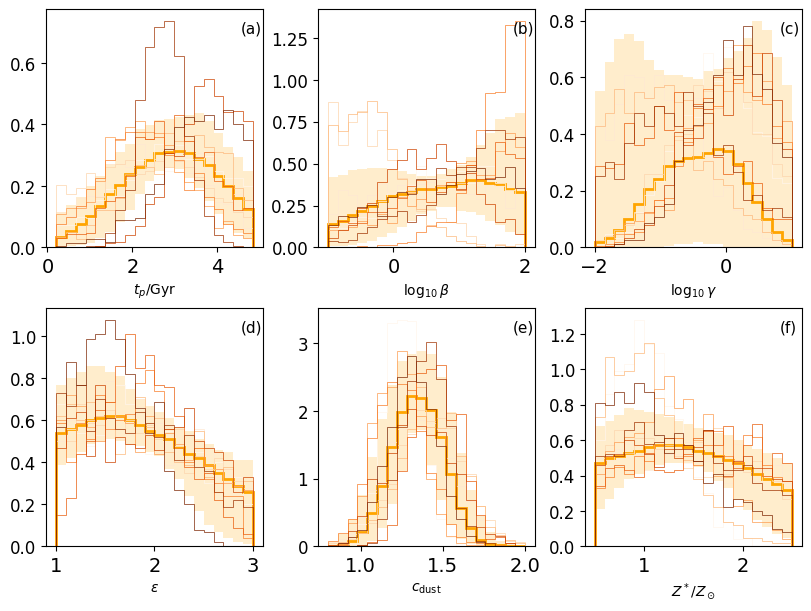

In [6]:
prior_params = bagpus.plotting.plot_params(fit.prior.sample((1000,)), model,
                                           nbins=20, ngal=1000)

/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


PLEASE NOTE tquench only includes distributions with >10 quenched galaxies


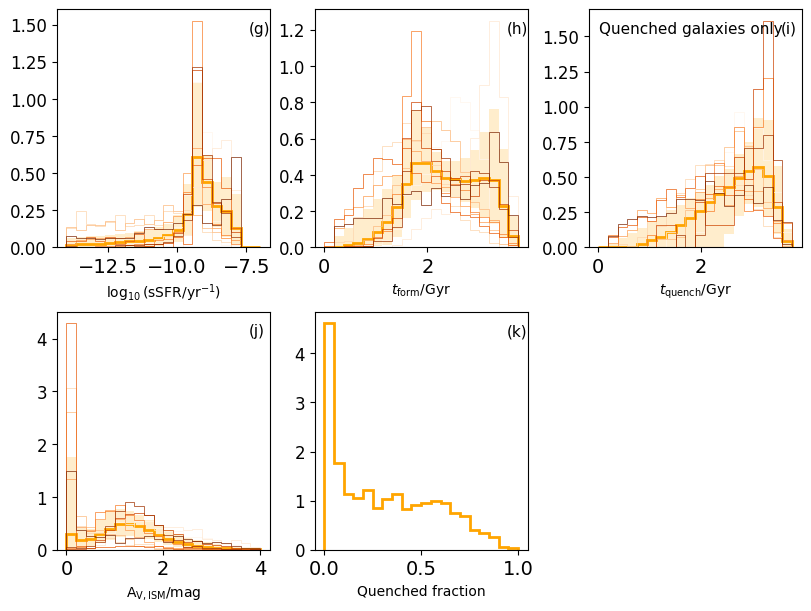

In [7]:
prior_derived = bagpus.plotting.plot_derived(
    fit.prior.sample((1000,)), model,
    ['ssfr', 'tform', 'tquench', 'Av', 'fquench'], nbins=20, ngal=1000)

## 5. Training data (slow — hours at full scale)

For the paper: two batches of 5000 simulations, each of 7000 galaxies. On a laptop, start with a few hundred to see the machinery work; for production use `scripts/step2_simulate.py` on a cluster then copy the files to the /runs/training/[run] directory.

In [8]:
theta_train, x_train = fit.simulate(nsims=5000, batch=1)   # loads instantly if already on disk
theta_test, x_test = fit.simulate_test(nsims=500)

Training batch 1 already exists — loading. Use force=True to regenerate.
Test set already exists — loading. Use force=True to regenerate.


## 6. Compression and neural posterior training

The 50×55 SC histograms are compressed to 20 PCA amplitudes; a masked autoregressive flow is trained to estimate the posterior over the 12 population hyperparameters.

In [9]:
posterior = fit.train(n_pca_components=20, diagnostic_plot=True)

Trained posterior already exists — loading. Use force=True to retrain.


### Check the PCA components

The images of the leading PCA components should show coherent structure, running into noise by the last few — if the final components still look structured, information is being thrown away and `n_pca_components` should be increased.

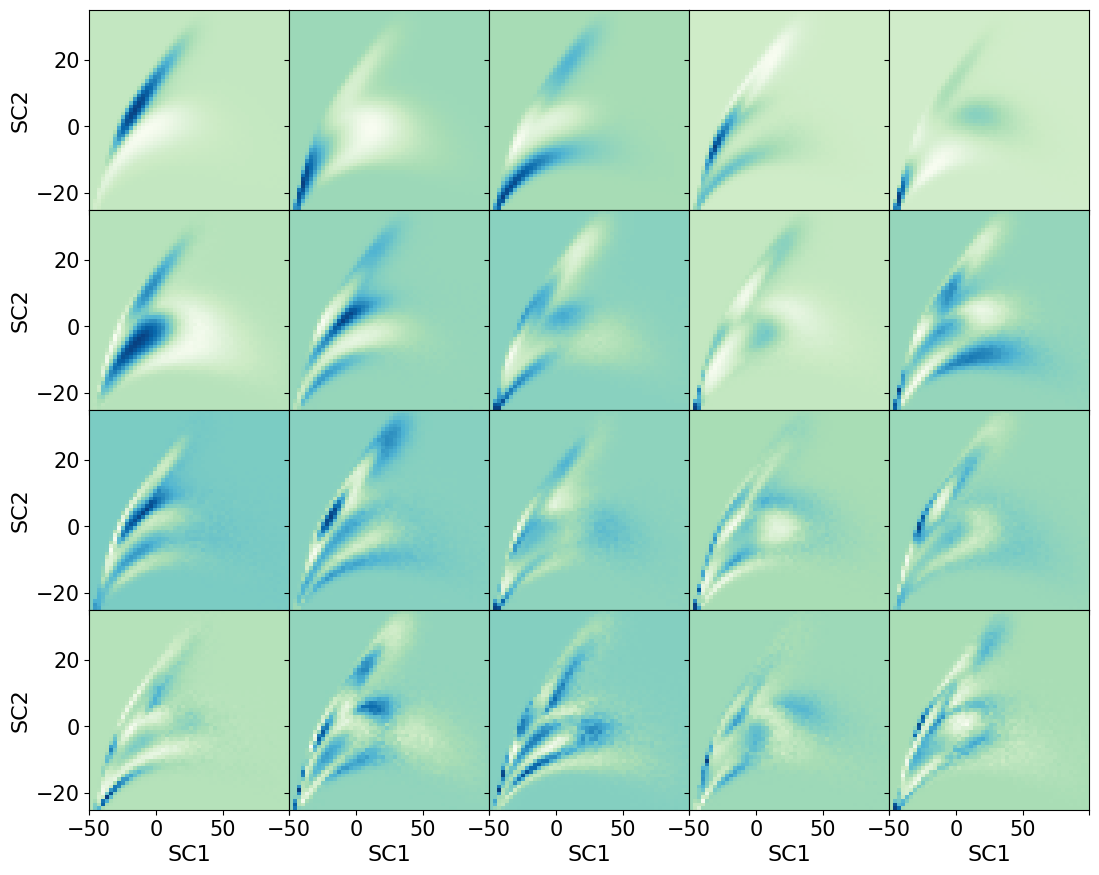

In [10]:
fit.plot_pca_components();

## 7. Posterior for the UDS data

We draw 1000 samples from the posterior to match the observations, and plot the corner plot to check we constrained something sensible. 

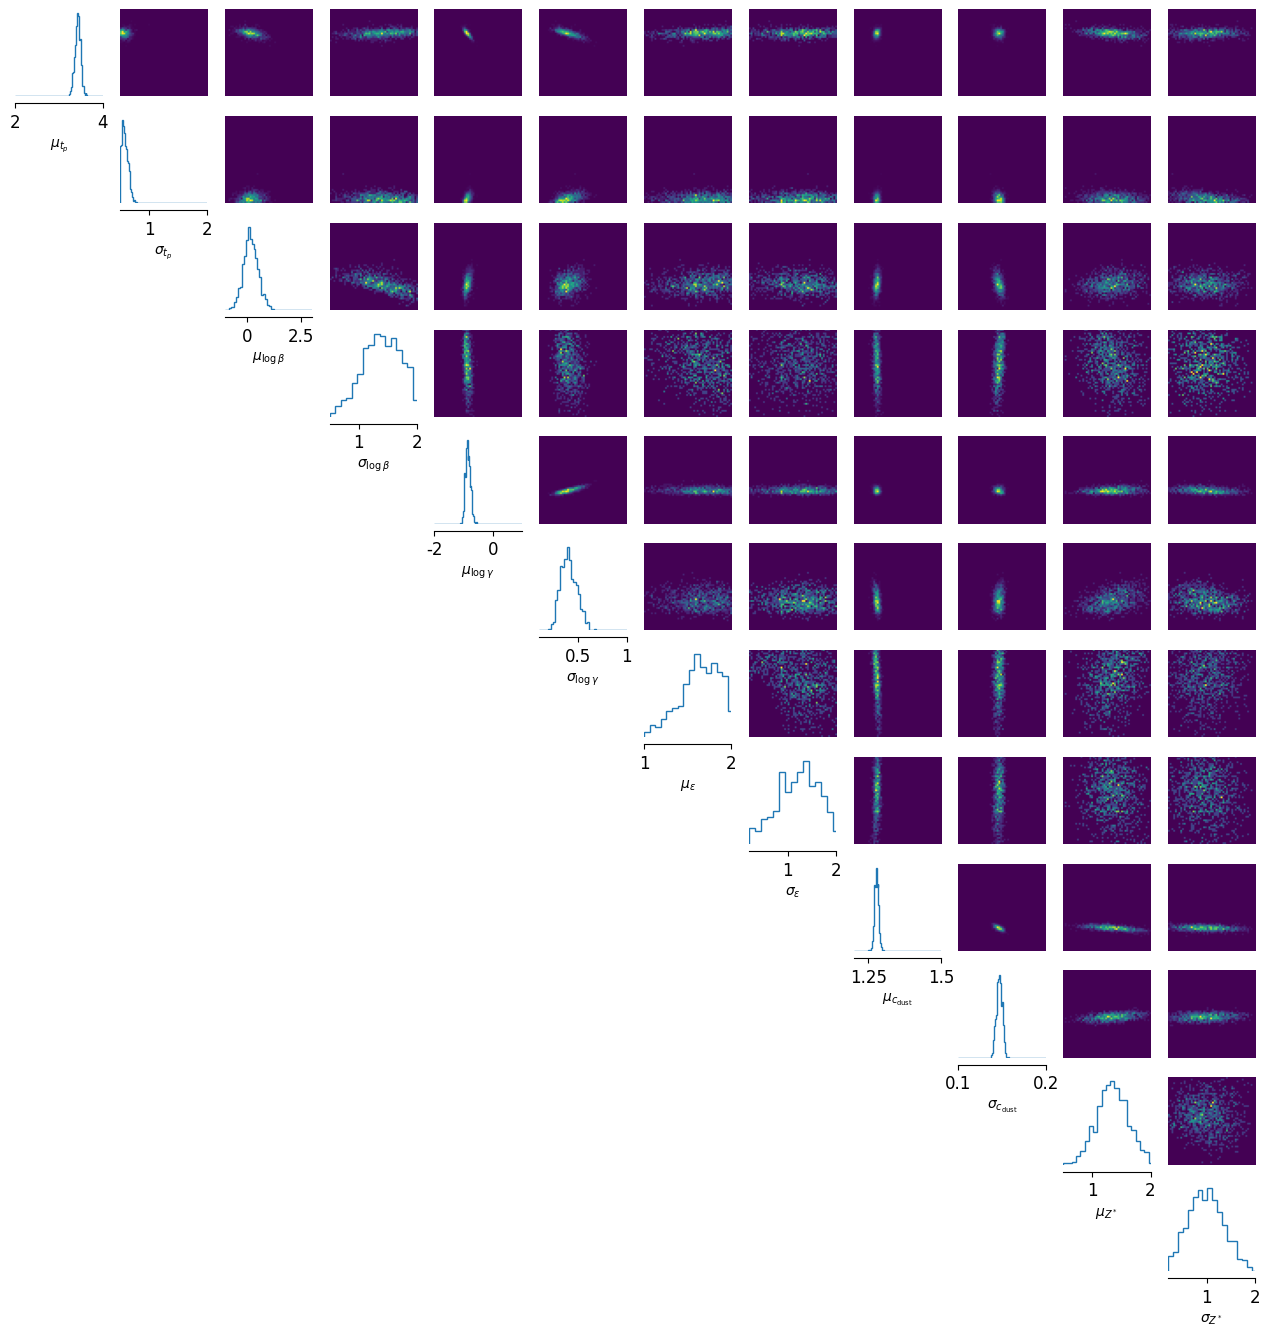

In [11]:
samples = fit.sample(n=1000)
fit.plot_corner();

### Posterior predictive checks

Forward-simulate posterior draws and compare with the observed SC distribution — both the maps and the normalised residuals.

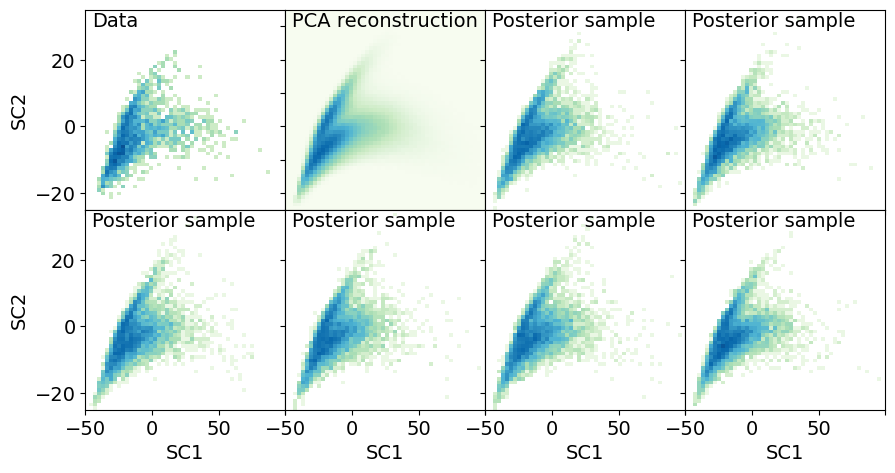

In [12]:
fit.plot_posterior_predictive();

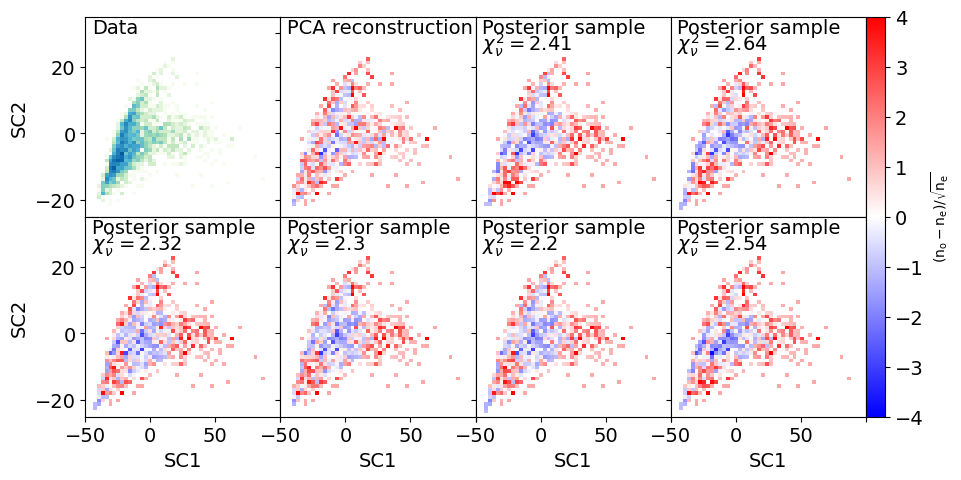

In [13]:
fit.plot_residuals();

number of samples in residuals stack: 100


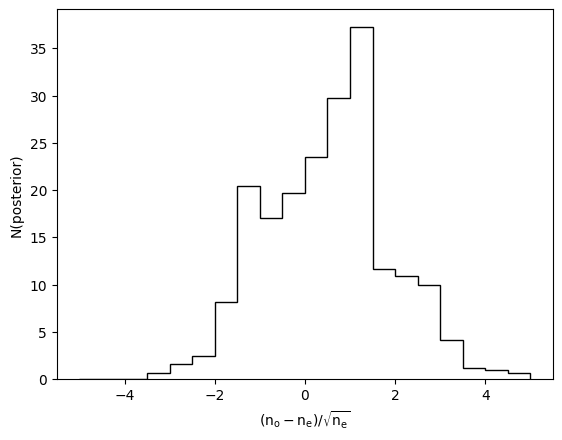

16th, 50th, 84th percentiles of chi^2 distribution: [2.1665358  2.32602388 2.55905367]

number with sigma<1: 516
number with sigma<5: 240
fraction within 1 sigma:  0.46511627906976744


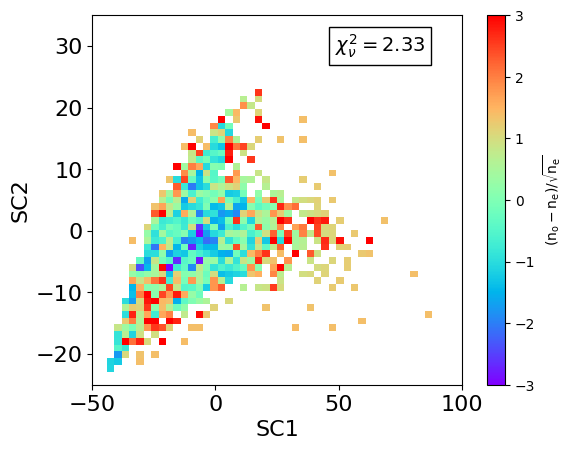

In [14]:
chisq = fit.plot_stacked_residuals()

## 8. Population parameters and derived properties

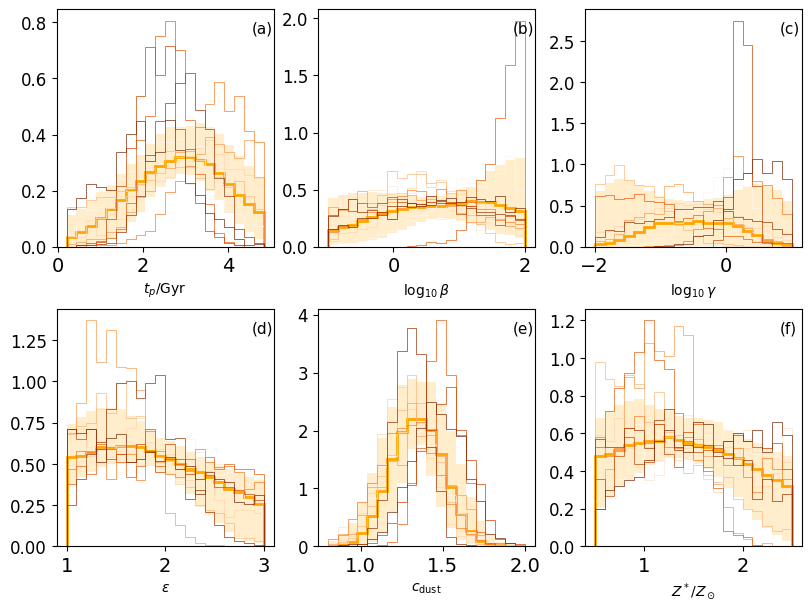

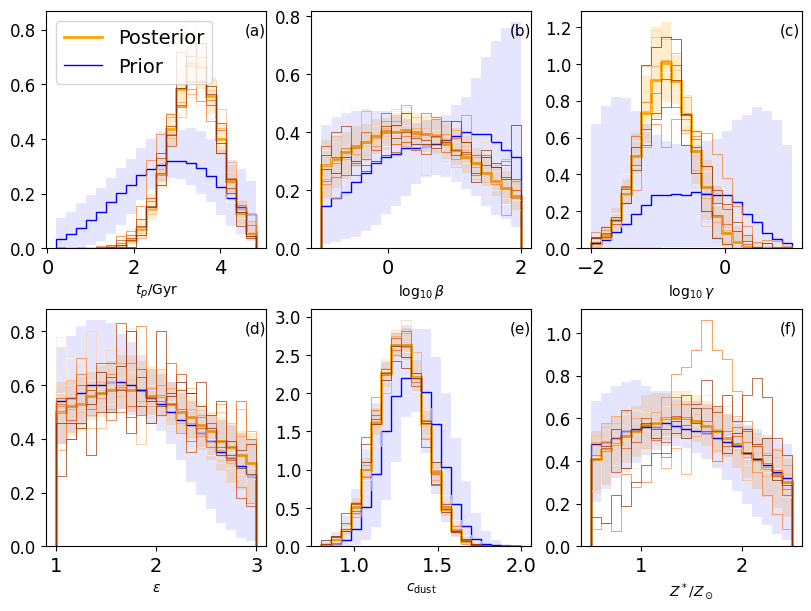

In [15]:
post_params = fit.plot_params()

/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


PLEASE NOTE tquench only includes distributions with >10 quenched galaxies


PLEASE NOTE tquench only includes distributions with >10 quenched galaxies


posterior quenched fraction [16,50,84]th percentiles: [0.212 0.231 0.247]


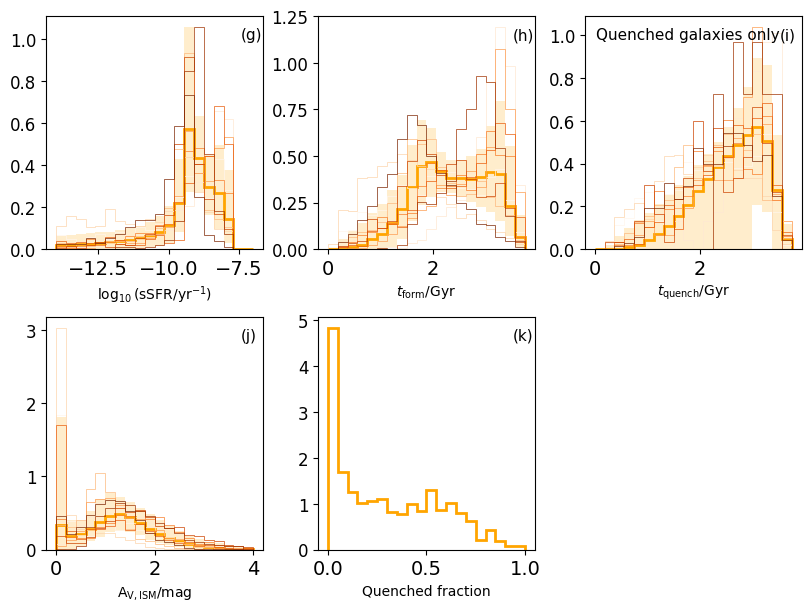

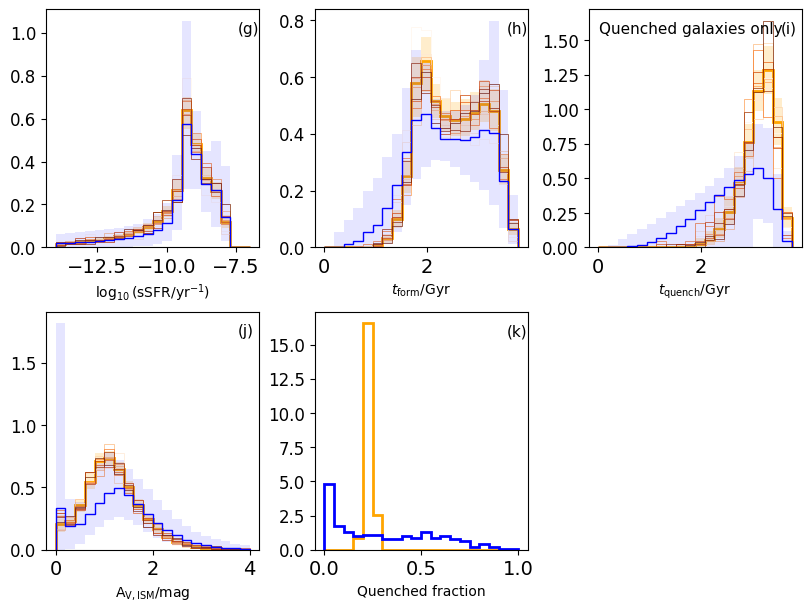

In [16]:
post_derived = fit.plot_derived()
print('posterior quenched fraction [16,50,84]th percentiles:',
      np.percentile(post_derived['fquench'], [16, 50, 84]))

In [17]:
fit.summary_table(latex=True)

\begin{table}
\begin{tabular}{cccc}
Name & 16th & median & 84th \\
$\mu_{t_p}$ & 3.36 & 3.43 & 3.49 \\
$\sigma_{t_p}$ & 0.53 & 0.57 & 0.64 \\
$\mu_{\log\beta}$ & -0.14 & 0.16 & 0.51 \\
$\sigma_{\log\beta}$ & 1.06 & 1.39 & 1.73 \\
$\mu_{\log\gamma}$ & -0.94 & -0.87 & -0.77 \\
$\sigma_{\log\gamma}$ & 0.32 & 0.40 & 0.49 \\
$\mu_\epsilon$ & 1.41 & 1.66 & 1.87 \\
$\sigma_\epsilon$ & 0.79 & 1.26 & 1.66 \\
$\mu_{c_{\rm dust}}$ & 1.27 & 1.28 & 1.28 \\
$\sigma_{c_{\rm dust}}$ & 0.14 & 0.15 & 0.15 \\
$\mu_{Z^*}$ & 1.08 & 1.34 & 1.61 \\
$\sigma_{Z^*}$ & 0.61 & 0.96 & 1.34 \\
\end{tabular}
\end{table}


Name,16th,median,84th
str23,float32,float32,float32
$\mu_{t_p}$,3.356822,3.4285355,3.4892778
$\sigma_{t_p}$,0.5287445,0.5744802,0.6424102
$\mu_{\log\beta}$,-0.13885838,0.15909919,0.5138811
$\sigma_{\log\beta}$,1.0564278,1.3905289,1.7317327
$\mu_{\log\gamma}$,-0.9422707,-0.8661776,-0.76980346
$\sigma_{\log\gamma}$,0.3184667,0.39562967,0.49195242
$\mu_\epsilon$,1.4094574,1.6589627,1.8698089
$\sigma_\epsilon$,0.7919566,1.2643371,1.6602821
$\mu_{c_{\rm dust}}$,1.2715203,1.2782254,1.284648


## 9. Quenching timescales and number densities

The population posterior gives distributions of quenching timescales
($\tau_{q,init}$: peak to half-peak SFR; $\tau_{q,full}$: peak to quenched) for the quenched galaxies, plus quenched fractions and — via the survey volume — comoving number densities at earlier epochs (the "fossil record").

The plot_pdf function can be used to plot any stats returned by quenching_statistics. With a little work, you can add your own of interest (e.g. try t90). 

In [18]:
stats = fit.quenching_statistics(omega_deg2=0.60,
                                 zbins=[2.33, 3.49, 4.32], ndraws=400)

for j, z in enumerate(stats['zbins']):
    pn = np.percentile(stats['nquench_zbin'][:, j], [16, 50, 84])
    print(f"z > {z}: n_q = {pn[1]:.2f} +{pn[2]-pn[1]:.2f} -{pn[1]-pn[0]:.2f} (1e-5 Mpc^-3)")

/opt/anaconda3/envs/sbi_env/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


z > 2.33: n_q = 4.61 +1.58 -1.26 (1e-5 Mpc^-3)
z > 3.49: n_q = 0.05 +0.10 -0.05 (1e-5 Mpc^-3)
z > 4.32: n_q = 0.00 +0.00 -0.00 (1e-5 Mpc^-3)


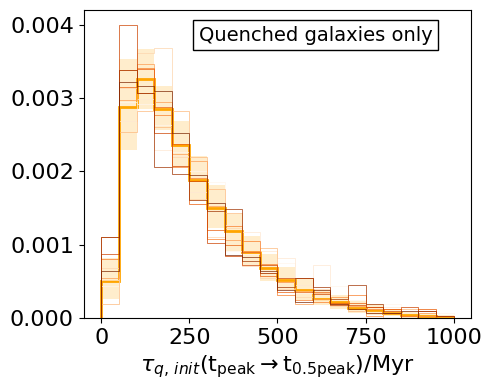

In [19]:
bagpus.plotting.plot_pdf(stats['pdf_tauquench_init'], stats['tauquench_init_edges'],
    r"$\tau_{q,\,init}({\rm t_{peak}\rightarrow t_{0.5peak}})$/Myr",
    'Quenched galaxies only');

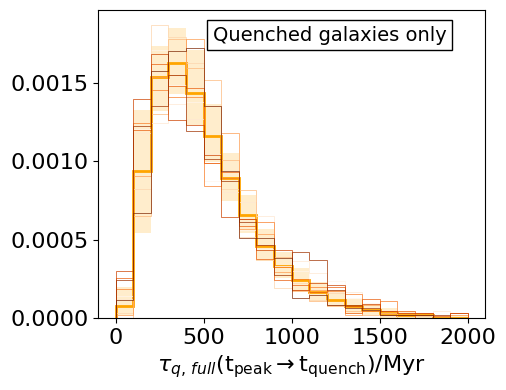

In [20]:
bagpus.plotting.plot_pdf(stats['pdf_tauquench_full'], stats['tauquench_full_edges'],
    r"$\tau_{q,\,full}({\rm t_{peak}\rightarrow t_{quench}})$/Myr",
    'Quenched galaxies only');

## Notes

* **Mock recovery tests** across prior space: simulate the test set (`fit.simulate_test`), then `fit.sample_mock(x_test[i])` for each test simulation and compare medians against `theta_test[i]`.
* **Why rapid quenching?** The paper shows the observed SC bimodality (in particular the PSB branch) cannot be reproduced without short quenching timescales — see Section 5.